# CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

**Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

## Resources
- [CIFAR-10 Dataset](https://www.cs.toronto.edu/~kriz/cifar.html)
- [TensorFlow Keras Documentation](https://www.tensorflow.org/api_docs/python/tf/keras)
- [Convolutional Neural Networks Explained](https://cs231n.github.io/convolutional-networks/)

# Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32x32x3**.
- 50,000 training images
- 10,000 test images

In [11]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Visualize Sample Images

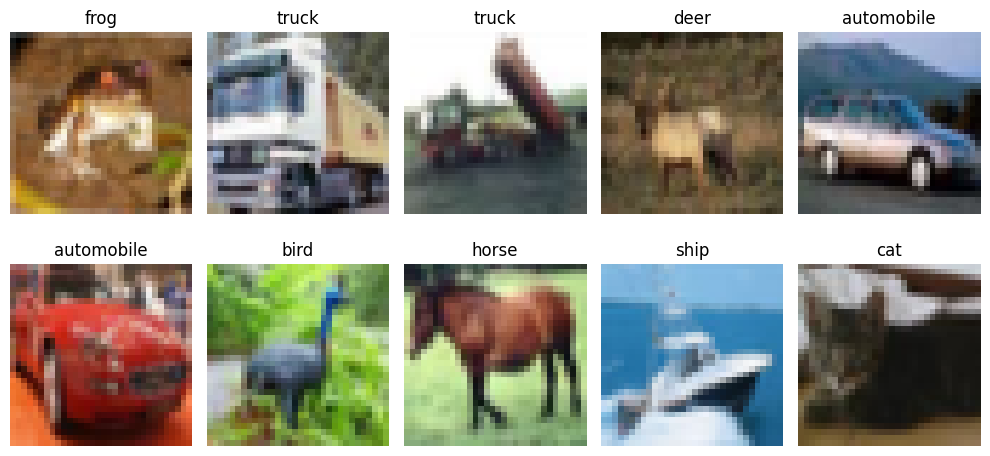

In [12]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [13]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [14]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.2577 - loss: 2.0175 - val_accuracy: 0.3142 - val_loss: 1.8489
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.3134 - loss: 1.8726 - val_accuracy: 0.3644 - val_loss: 1.7784
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3390 - loss: 1.8106 - val_accuracy: 0.3780 - val_loss: 1.7351
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3509 - loss: 1.7844 - val_accuracy: 0.3954 - val_loss: 1.7051
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3606 - loss: 1.7619 - val_accuracy: 0.3952 - val_loss: 1.7060
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.3658 - loss: 1.7381 - val_accuracy: 0.4044 - val_loss: 1.7044
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.3742 - loss: 1.7263 - val_accuracy: 0.3930 - val_loss: 1.7250
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3804 - loss: 1.7052 - 

In [15]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4281 - loss: 1.6561
ANN Test Accuracy: 0.42809998989105225


# Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [16]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 127ms/step - accuracy: 0.4668 - loss: 1.5016 - val_accuracy: 0.5246 - val_loss: 1.3222
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.6067 - loss: 1.1272 - val_accuracy: 0.6396 - val_loss: 1.0358
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 135ms/step - accuracy: 0.6687 - loss: 0.9496 - val_accuracy: 0.6396 - val_loss: 1.0274
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.7154 - loss: 0.8262 - val_accuracy: 0.6240 - val_loss: 1.1115
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 120ms/step - accuracy: 0.7459 - loss: 0.7379 - val_accuracy: 0.6814 - val_loss: 0.9229
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.7687 - loss: 0.6582 - val_accuracy: 0.7010 - val_loss: 0.8588
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 123ms/step - accuracy: 0.7938 - loss: 0.5902 - val_accuracy: 0.7290 - val_loss: 0.8132
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 120ms/step - accuracy: 0.8130 - loss

In [17]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7173 - loss: 0.9150
CNN Test Accuracy: 0.7172999978065491


# Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [26]:
# Combined Augmented CNN Model Definition, Training, and Evaluation

# 1. Define Data Augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# 2. Define the Augmented CNN Model
aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

# 3. Compile the Augmented CNN Model
aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# 4. Train the Augmented CNN Model
print("\n--- Training Augmented CNN Model ---")
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

# 5. Evaluate the Augmented CNN Model
print("\n--- Evaluating Augmented CNN Model ---")
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_cnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Augmented CNN Model ---
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 93ms/step - accuracy: 0.3652 - loss: 1.7383 - val_accuracy: 0.4432 - val_loss: 1.5919
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.4627 - loss: 1.4949 - val_accuracy: 0.5324 - val_loss: 1.3133
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 93ms/step - accuracy: 0.4964 - loss: 1.4080 - val_accuracy: 0.5184 - val_loss: 1.3457
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.5243 - loss: 1.3420 - val_accuracy: 0.5734 - val_loss: 1.2075
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5418 - loss: 1.2937 - val_accuracy: 0.5722 - val_loss: 1.2407
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.5526 - loss: 1.2613 - val_accuracy: 0.6198 - val_loss: 1.0677
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.5615 - loss: 1.2361 - val_accuracy: 0.6380 - val_loss: 1.0292
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/ste

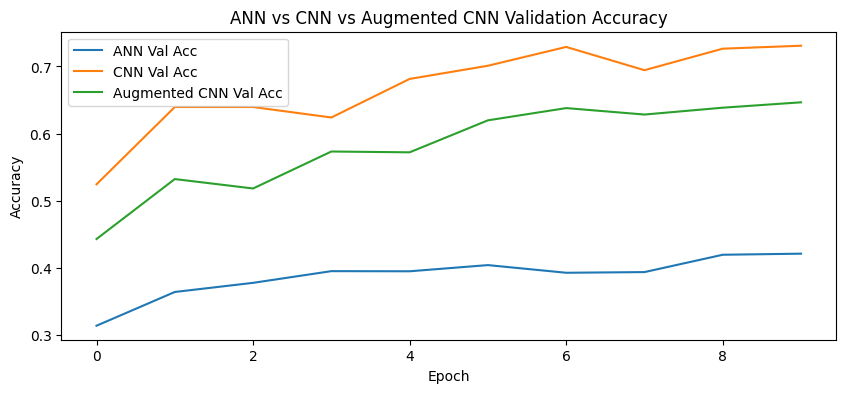


--- Comparison Table ---


,Model,Test Accuracy
0,ANN,0.4281
1,CNN,0.7173
2,Augmented CNN,0.6404


In [27]:
# Combined Comparison Plot and Table

# Plot comparison of validation accuracy
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN vs Augmented CNN Validation Accuracy")
plt.legend()
plt.show()

# Display final comparison table
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_cnn_test_acc]
})
print("\n--- Comparison Table ---")
display(comparison)

# Final Comparison Table

In [28]:
# Re-run this cell to evaluate the Augmented CNN model and define 'aug_cnn_test_acc'
aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6404 - loss: 1.0333
Augmented CNN Test Accuracy: 0.6403999924659729


In [29]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4281
1,CNN,0.7173
2,Augmented CNN,0.6404


# Student Learning Tasks
Try these tasks after understanding the notebook:

### Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**